# Task 3: Distributions and relationships

Missing measurements are handled explicitly before plotting.


In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("data")
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GREY, QUIET = "#b8b8b8", "#cfceca"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "axes.titleweight": "bold",
})

penguins = pd.read_csv(DATA / "penguins.csv")
measurement_columns = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
print(penguins[measurement_columns + ["sex"]].isna().sum())
measurements = penguins.dropna(subset=measurement_columns).copy()
measurements["sex"] = measurements["sex"].str.title()
print(f"Excluded {len(penguins) - len(measurements)} rows missing all four measurements.")

bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
Excluded 2 rows missing all four measurements.


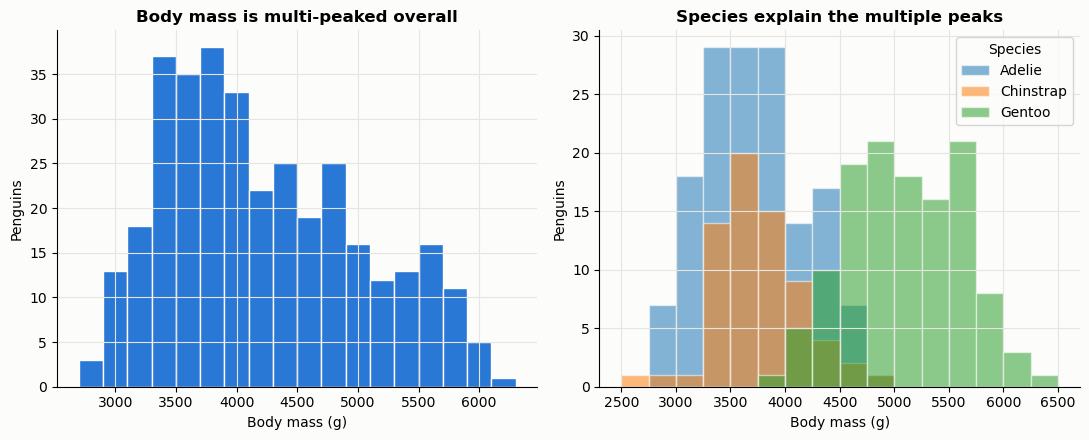

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(measurements["body_mass_g"], bins=18, color=BLUE, edgecolor="#fcfcfb")
axes[0].set_title("Body mass is multi-peaked overall"); axes[0].set_xlabel("Body mass (g)"); axes[0].set_ylabel("Penguins")
for species, group in measurements.groupby("species"):
    axes[1].hist(group["body_mass_g"], bins=np.arange(2500, 6501, 250), alpha=0.55, label=species, edgecolor="#fcfcfb")
axes[1].set_title("Species explain the multiple peaks"); axes[1].set_xlabel("Body mass (g)"); axes[1].set_ylabel("Penguins"); axes[1].legend(title="Species")
fig.tight_layout(); plt.show()


### Distribution explanation

A histogram is appropriate because the question asks for the shape of one numeric variable. The species split shows that the multiple humps largely come from combining species with different typical body masses. The two rows missing all four measurements are excluded.


Adelie within-group correlation: 0.39
Chinstrap within-group correlation: 0.65
Gentoo within-group correlation: 0.64
All-species correlation: -0.24


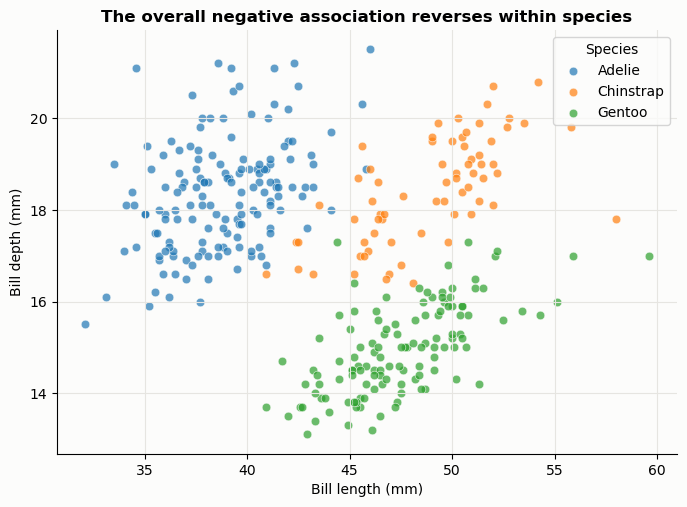

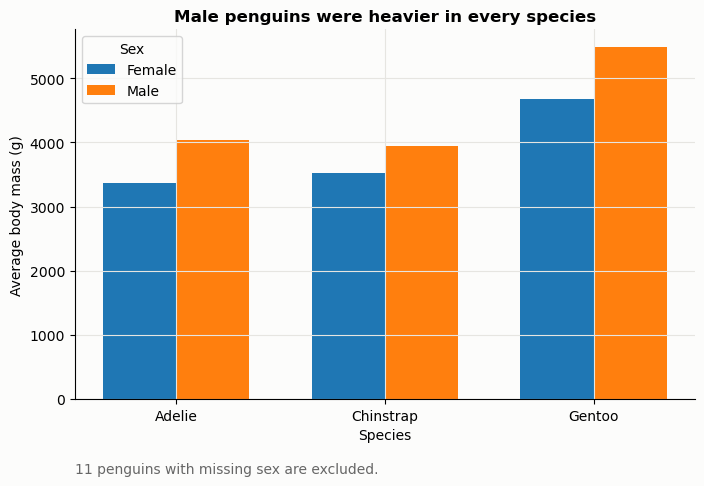

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for species, group in measurements.groupby("species"):
    ax.scatter(group["bill_length_mm"], group["bill_depth_mm"], s=38, alpha=0.7, label=species, edgecolor="#fcfcfb", linewidth=0.5)
    print(f"{species} within-group correlation: {group['bill_length_mm'].corr(group['bill_depth_mm']):.2f}")
print(f"All-species correlation: {measurements['bill_length_mm'].corr(measurements['bill_depth_mm']):.2f}")
ax.set_title("The overall negative association reverses within species")
ax.set_xlabel("Bill length (mm)"); ax.set_ylabel("Bill depth (mm)"); ax.legend(title="Species"); plt.show()

sex_mass = measurements.dropna(subset=["sex"]).groupby(["species", "sex"], as_index=False)["body_mass_g"].mean()
fig, ax = plt.subplots(figsize=(8, 4.8)); species_order = ["Adelie", "Chinstrap", "Gentoo"]; positions = np.arange(3); width = 0.35
for offset, sex in zip([-width / 2, width / 2], ["Female", "Male"]):
    values = [sex_mass.query("species == @species and sex == @sex")["body_mass_g"].iloc[0] for species in species_order]
    ax.bar(positions + offset, values, width=width, label=sex)
ax.set_title("Male penguins were heavier in every species"); ax.set_xlabel("Species"); ax.set_ylabel("Average body mass (g)")
ax.set_xticks(positions, species_order); ax.legend(title="Sex"); ax.text(0, -0.2, "11 penguins with missing sex are excluded.", transform=ax.transAxes, color="#666666"); plt.show()


### Simpson's paradox and missing sex values

Across all penguins, the larger-bodied species create a negative association between bill length and depth. Within each species, the association is positive. This is Simpson's paradox: the aggregate direction reverses after the relevant groups are separated. The sex comparison excludes the 11 penguins with missing sex because they cannot be assigned to a sex group. The scatter plot is the right chart for the relationship, and the grouped bars are appropriate for comparing means across species and sex.
